## Часть 1. Исследование многомерного нормального распределения (10 баллов)

### 1.1 Генерация данных с заданной ковариацией
**Цель:** научиться генерировать данные с контролируемой структурой зависимости.

1. Создайте $ M = 500 $ точек в двумерном пространстве:
   - Сгенерируйте два независимых вектора: $ x_1 \sim \mathcal{N}(0, \sigma_1^2) $, $ x_2 \sim \mathcal{N}(0, \sigma_2^2) $, где $ \sigma_1 = 0.3 $, $ \sigma_2 = 0.8 $.
2. Примените матрицу поворота на угол $ \alpha = 30^\circ $:
   $
   R = \begin{bmatrix} \cos\alpha & -\sin\alpha \\ \sin\alpha & \cos\alpha \end{bmatrix}
   $
3. Выведите на экран **выборочную матрицу ковариации** (через `np.cov`).
4. Сравните с теоретической: $ C_{теор} = R \cdot \text{diag}(\sigma_1^2, \sigma_2^2) \cdot R^T $.

**Визуализация:**
- Постройте scatter plot полученных точек.
- На том же графике (используя `plt.contour`) нарисуйте эллипсы равной плотности для теоретического распределения (на уровнях 0.5, 1, 2 стандартных отклонения).

**Автопроверка:**
```python
# Проверка: размерность и наличие поворота
assert X.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X.T)[0, 1]) > 0.1, "Корреляция слишком мала (проверьте поворот)"
assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), "Среднее должно быть около 0"
```

Выборочная ковариация:
 [[ 0.23312293 -0.23625764]
 [-0.23625764  0.46568054]]
Теоретическая ковариация:
 [[ 0.2275     -0.23815699]
 [-0.23815699  0.5025    ]]

Разница (выборочная - теоретическая):
 [[ 0.00562293  0.00189935]
 [ 0.00189935 -0.03681946]]


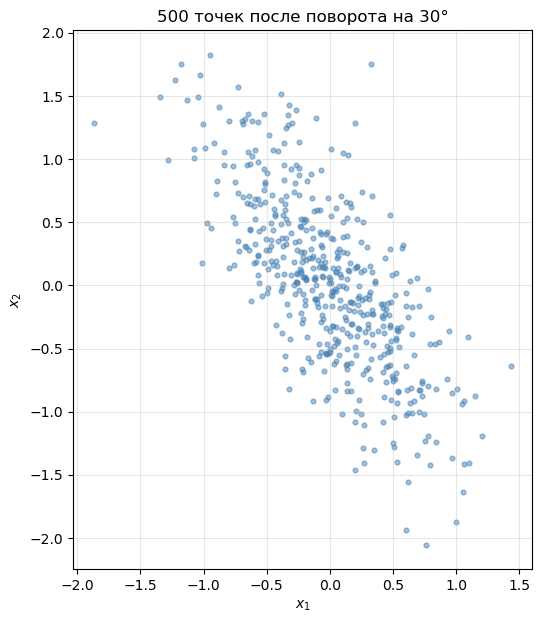

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

np.random.seed(42)
M = int(500)
sigma1 = 0.3
sigma2 = 0.8

# Генерируем два независимых вектора длины 500
x1 = np.random.normal(loc=0.0, scale=sigma1, size=M)
x2 = np.random.normal(loc=0.0, scale=sigma2, size=M)

# Собираем их в матрицу (500, 2)
X_raw = np.column_stack([x1, x2])

# Задаём значение в 30 градусов
alpha_deg = 30
# Переводим 30 градусов в радианы
alpha = np.deg2rad(30)
# Создаём матрицу поворота с углом 30 градцсов
R = np.array([
    [np.cos(alpha), -np.sin(alpha)],
    [np.sin(alpha),  np.cos(alpha)]
])
X = X_raw @ R.T

# Записываем случайную матрицу ковариации и выводим результат на экран
cov_sample = np.cov(X.T)
print("Выборочная ковариация:\n", cov_sample)

# Проверим случайную ковариацию с треоретической (истинной)
# Создаём диагональную матрицу со сзначениями 0,3*2, 0,8*2
Sigma_raw = np.diag([sigma1**2, sigma2**2])
# Правило преобразования ковариации при линейном преобразовании
# Получили теоретическую матрицу ковариации
C_theor = R @ Sigma_raw @ R.T
print("Теоретическая ковариация:\n", C_theor)
# Сравним две матрицы
diff = cov_sample - C_theor
print("\nРазница (выборочная - теоретическая):\n", diff)

# Переходим к строительству графика
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(X[:, 0], X[:, 1], s=12, alpha=0.5, color='steelblue')

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('500 точек после поворота на 30°')
ax.set_aspect('equal')
ax.grid(alpha=0.3)

plt.show()

# Проверка: размерность и наличие поворота 676767676767677652522525252252222522
assert X.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X.T)[0, 1]) > 0.1, "Корреляция слишком мала (проверьте поворот)"
assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), "Среднее должно быть около 0"

### 1.2 Сравнение с встроенной функцией
- Сгенерируйте точки с помощью `np.random.multivariate_normal` с той же матрицей ковариации.
- Нарисуйте оба облака точек на одном графике разными цветами.
- **Вопрос (ответить текстом в Markdown):** совпадают ли облака визуально? Почему встроенная функция может быть предпочтительнее?

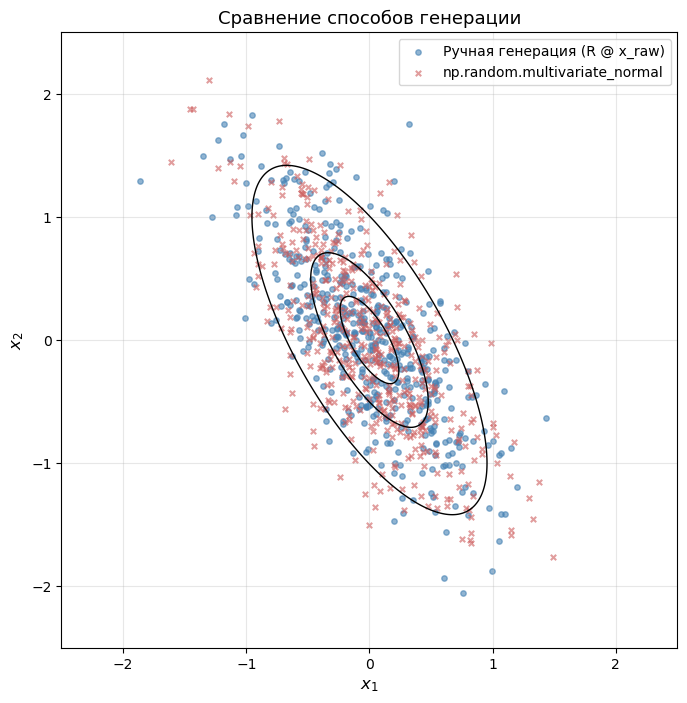

In [46]:
X_builtin = np.random.multivariate_normal(
    mean=[0, 0],
    cov=C_theor,
    size=M
)

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(X[:, 0], X[:, 1],
           s=15, alpha=0.6, color='steelblue',
           label='Ручная генерация (R @ x_raw)')

ax.scatter(X_builtin[:, 0], X_builtin[:, 1],
           s=15, alpha=0.6, color='indianred', marker='x',
           label='np.random.multivariate_normal')

# Эллипсы теоретического распределения — для ориентира
gx = np.linspace(-2.5, 2.5, 400)
gy = np.linspace(-2.5, 2.5, 400)
GX, GY = np.meshgrid(gx, gy)
pos = np.dstack([GX, GY])
Z = multivariate_normal([0, 0], C_theor).pdf(pos)

det_C = np.linalg.det(C_theor)
levels = [np.exp(-k**2 / 2) / (2 * np.pi * np.sqrt(det_C))
          for k in [0.5, 1.0, 2.0][::-1]]
ax.contour(GX, GY, Z, levels=levels, colors='black', linewidths=1)

ax.set_xlabel('$x_1$', fontsize=12)
ax.set_ylabel('$x_2$', fontsize=12)
ax.set_title('Сравнение способов генерации', fontsize=13)
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.legend(loc='upper right')
plt.show()

### Ответ на вопрос 1.2

Визуально облака совпадают.
Почему предпочтительнее встроенная функция:
* Встроенной функции без разницы какая структура у нашей матрицы С, она работает с любой, в отличии от ручной генерации.
* Разложение Холецкого может работать с очень маленькими собственными значениями, не требуя структуру $R \Sigma R^T$.
* Меньше кода, так как функция встроенна и корректно работает в отличии от ручной генерации.

## Часть 2. Визуализация плотности вероятности (5 баллов)

**Цель:** научиться вычислять и визуализировать PDF многомерного нормального распределения.

1. По данным из пункта 1.1 оцените $ \hat{\mu} $ и $ \hat{C} $ (выборочные).
2. Создайте сетку точек в диапазоне от -2 до 2 по обеим осям.
3. Вычислите плотность вероятности в каждой точке сетки **двумя способами**:
   - С помощью `scipy.stats.multivariate_normal(mean=mu, cov=C).pdf()`.
   - Самостоятельно по формуле (1) из задания (используйте `np.linalg.det` и `np.linalg.inv`).
4. Сравните результаты (максимальная разница должна быть < 1e-10).

**Визуализация:**
- Постройте contour plot с заливкой (используя `plt.contourf`).
- Добавьте линии уровня (contour) с подписями значений.
- Нанесите исходные точки поверх фона.

**Автопроверка:**
```python
# Проверка ручного вычисления
pdf_manual = ... # ваша реализация
pdf_scipy = m.pdf(grid_points)
assert np.allclose(pdf_manual, pdf_scipy, atol=1e-8), "Ручное вычисление отличается от scipy"
```

In [5]:
# Оцениваю $ \hat{\mu} $ и $ \hat{C} $ (выборочные).

# Выборочное среднее — вектор длины 2
mu_hat = np.mean(X, axis=0)

# Выборочная ковариационная матрица — матрица 2x2
C_hat = np.cov(X.T)

# Вывод на экран
print("mu_hat =", mu_hat)
print("Форма mu_hat:", mu_hat.shape)
print()
print("C_hat =")
print(C_hat)
print("Форма C_hat:", C_hat.shape)

mu_hat = [-0.01095388  0.02307548]
Форма mu_hat: (2,)

C_hat =
[[ 0.23312293 -0.23625764]
 [-0.23625764  0.46568054]]
Форма C_hat: (2, 2)


Оценки близки к истинным параметрам: расхождения порядка 10^{−2}, что соответствует статистической ошибке выборки из M = 500 точек

In [9]:
# Разметка осей: 200 равномерных точек на каждой оси
n_grid = 200
gx = np.linspace(-2, 2, n_grid)   # вектор длины 200 для оси x1
gy = np.linspace(-2, 2, n_grid)   # вектор длины 200 для оси x2

# Сетка: две матрицы формы (200, 200)
GX, GY = np.meshgrid(gx, gy)

# Собираем координаты каждой точки в один массив формы (40000, 2)
grid_points = np.dstack([GX, GY]).reshape(-1, 2)

from scipy.stats import multivariate_normal

# Вычисляю плотность вероятности в каждой точке сетки

# 1. Через scipy
m = multivariate_normal(mean=mu_hat, cov=C_hat)
pdf_scipy = m.pdf(grid_points).reshape(GX.shape)

print("pdf_scipy.shape:", pdf_scipy.shape)
print("Максимум pdf_scipy:", pdf_scipy.max())
print("Минимум pdf_scipy:", pdf_scipy.min())

# 2. Вручную по формуле
def mvn_pdf_manual(x, mu, cov):
    d = mu.shape[0]
    diff = x - mu                          
    inv_cov = np.linalg.inv(cov)           
    det_cov = np.linalg.det(cov)           
    
    # Нормировочная константа: 1 / ((2π)^(d/2) * |C|^(1/2))
    norm_const = 1.0 / np.sqrt((2 * np.pi) ** d * det_cov)
    
    # Квадратичная форма (x-μ)^T C^{-1} (x-μ) для каждой точки
    exponent = -0.5 * np.einsum('ij,jk,ik->i', diff, inv_cov, diff)
    
    return norm_const * np.exp(exponent)

pdf_manual_flat = mvn_pdf_manual(grid_points, mu_hat, C_hat)
pdf_manual = pdf_manual_flat.reshape(GX.shape)

print("\npdf_manual.shape:", pdf_manual.shape)
print("Максимум pdf_manual:", pdf_manual.max())
print("Минимум pdf_manual:", pdf_manual.min())

# Сравнение
max_diff = np.max(np.abs(pdf_manual - pdf_scipy))
print(f"\nМаксимальная разница: {max_diff:.2e}")

pdf_scipy.shape: (200, 200)
Максимум pdf_scipy: 0.6929072354379007
Минимум pdf_scipy: 3.155960490430567e-20

pdf_manual.shape: (200, 200)
Максимум pdf_manual: 0.6929072354379004
Минимум pdf_manual: 3.155960490430568e-20

Максимальная разница: 3.33e-16


Ручное вычисление PDF полностью совпадает со scipy.stats.multivariate_normal.pdf — расхождение на уровне машинной точности 

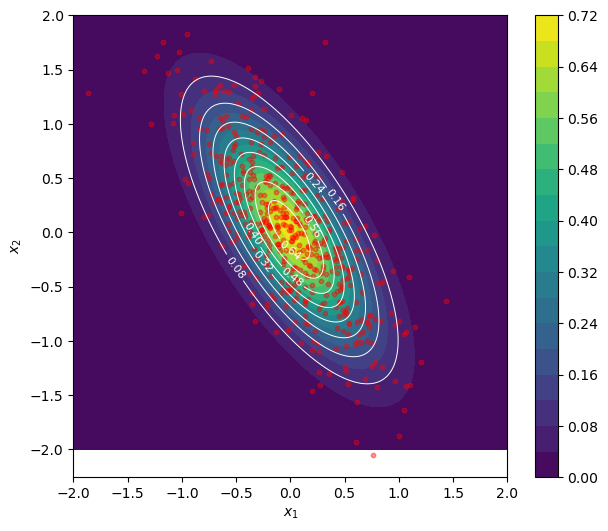

In [11]:
# Визуализация

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))

# 1. Заливка фона
cf = ax.contourf(GX, GY, pdf_manual, levels=20, cmap='viridis')

# 2. Линии уровня с подписями
cs = ax.contour(GX, GY, pdf_manual, levels=10, colors='white', linewidths=0.7)
ax.clabel(cs, inline=True, fontsize=8, fmt='%.2f')

# 3. Точки поверх фона
ax.scatter(X[:, 0], X[:, 1], s=10, alpha=0.4, color='red')

# 4. Минимальное оформление
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_aspect('equal')
plt.colorbar(cf, ax=ax)

plt.show()

In [18]:
# Автопроверка

pdf_manual = mvn_pdf_manual(grid_points, mu_hat, C_hat)

# 2. PDF через scipy
pdf_scipy = m.pdf(grid_points)

# 3. Проверка
assert np.allclose(pdf_manual, pdf_scipy, atol=1e-8), \
    "Ручное вычисление отличается от scipy"

print("Автопроверка пройдена, ручное вычисление совпадает со scipy")

Автопроверка пройдена, ручное вычисление совпадает со scipy


## Часть 3. Бинарная классификация через байесовский подход (15 баллов)

**Цель:** визуализировать разделяющую поверхность для двух классов.

### 3.1 Генерация датасета
Создайте два класса (по 300 точек каждый):
- **Класс 0:** $ \mu_0 = (-0.5, 0.5) $, $ C_0 = \begin{bmatrix} 0.2 & 0.1 \\ 0.1 & 0.3 \end{bmatrix} $
- **Класс 1:** $ \mu_1 = (0.5, -0.5) $, $ C_1 = \begin{bmatrix} 0.3 & -0.1 \\ -0.1 & 0.2 \end{bmatrix} $

In [22]:
# Явные приведения к Python-типам — защита от Sage-обёрток
np.random.seed(int(0))
n_per_class = int(300)

# Параметры классов
mu0 = np.array([-0.5,  0.5], dtype=np.float64)
mu1 = np.array([ 0.5, -0.5], dtype=np.float64)

C0 = np.array([[ 0.2,  0.1],
               [ 0.1,  0.3]], dtype=np.float64)
C1 = np.array([[ 0.3, -0.1],
               [-0.1,  0.2]], dtype=np.float64)

# Генерируем точки каждого класса
X0 = np.random.multivariate_normal(mu0, C0, n_per_class)
X1 = np.random.multivariate_normal(mu1, C1, n_per_class)

# Явно приводим к нативному numpy-массиву (на случай, если Sage вернул свой тип)
X0 = np.asarray(X0, dtype=np.float64)
X1 = np.asarray(X1, dtype=np.float64)

# Объединяем в один датасет
X_cls = np.vstack([X0, X1])
y_cls = np.hstack([np.zeros(n_per_class), np.ones(n_per_class)])

# Приводим y_cls тоже к numpy
y_cls = np.asarray(y_cls, dtype=np.float64)

# Вывод
print("Класс 0:", int(np.sum(y_cls == 0)), "точек")
print("Класс 1:", int(np.sum(y_cls == 1)), "точек")
print()
# Это отдельные матрицы каждого класса до объединения.
print("X0.shape:", X0.shape)
print("X1.shape:", X1.shape)

Класс 0: 300 точек
Класс 1: 300 точек

X0.shape: (300, 2)
X1.shape: (300, 2)


### 3.2 Визуализация апостериорной вероятности
Для каждой точки сетки вычислите:
$
\Delta(x) = p(x|y=0) \cdot p(y=0) - p(x|y=1) \cdot p(y=1)
$
где $ p(y) $ оценивается как доля объектов класса в выборке.

**Визуализация:**
- Scatter plot точек классов (разными цветами).
- Заливка фона: положительные значения $ \Delta $ — одним цветом (например, синим), отрицательные — другим (красным).
- Линия, где $ \Delta(x) = 0 $ (разделяющая поверхность) — через `plt.contour(..., levels=[0])`.

**Вопрос (ответить текстом):** является ли разделяющая поверхность линейной? Почему?

In [29]:
prior0 = np.mean(y_cls == 0)   # = 0.5
prior1 = np.mean(y_cls == 1)   # = 0.5

print("prior0 =", prior0)
print("prior1 =", prior1)

# Средние по каждому классу
mu0_hat = np.mean(X0, axis=0)   # (2,)
mu1_hat = np.mean(X1, axis=0)   # (2,)

# Ковариации по каждому классу (отдельно!)
C0_hat = np.cov(X0.T)           # (2, 2)
C1_hat = np.cov(X1.T)           # (2, 2)

print("mu0_hat:", mu0_hat)
print("mu1_hat:", mu1_hat)
print("\nC0_hat:\n", C0_hat)
print("\nC1_hat:\n", C1_hat)

# Сетка — диапазон чуть шире, чем в части 2, потому что классы разнесены на (-0.5, 0.5) и (0.5, -0.5)
n_grid = 300
gx = np.linspace(-3, 3, n_grid)
gy = np.linspace(-3, 3, n_grid)
GX, GY = np.meshgrid(gx, gy)
grid_points = np.dstack([GX, GY]).reshape(-1, 2)

print("grid_points.shape:", grid_points.shape)   # (90000, 2)

# PDF каждого класса в каждой точке сетки
pdf0 = multivariate_normal(mu0_hat, C0_hat).pdf(grid_points)  # (90000,)
pdf1 = multivariate_normal(mu1_hat, C1_hat).pdf(grid_points)  # (90000,)

# Δ(x) = p(x|0)·p(0) − p(x|1)·p(1)
Delta = (pdf0 * prior0 - pdf1 * prior1).reshape(GX.shape)     # (300, 300)

print("Delta.shape:", Delta.shape)
print("Delta min:", Delta.min())
print("Delta max:", Delta.max())

prior0 = 0.5
prior1 = 0.5
mu0_hat: [-0.46524623  0.53895353]
mu1_hat: [ 0.46069162 -0.49269603]

C0_hat:
 [[0.20254877 0.10479949]
 [0.10479949 0.30570198]]

C1_hat:
 [[ 0.26472085 -0.08579927]
 [-0.08579927  0.18221377]]
grid_points.shape: (90000, 2)
Delta.shape: (300, 300)
Delta min: -0.39307388947574723
Delta max: 0.3400669896370172


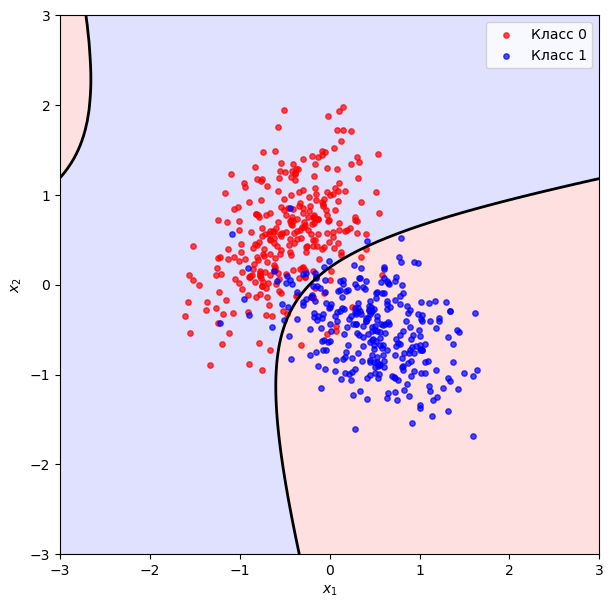

In [30]:
# Визуализация

fig, ax = plt.subplots(figsize=(8, 7))

# Заливка фона: Δ>0 — светло-красный, Δ<0 — светло-синий
ax.contourf(GX, GY, Delta,
            levels=[Delta.min(), 0, Delta.max()],
            colors=['#ffcccc', '#ccccff'],
            alpha=0.6)

# Разделяющая линия Δ=0
ax.contour(GX, GY, Delta, levels=[0], colors='black', linewidths=2)

# Точки классов
ax.scatter(X0[:, 0], X0[:, 1], s=15, c='red',  label='Класс 0', alpha=0.7)
ax.scatter(X1[:, 0], X1[:, 1], s=15, c='blue', label='Класс 1', alpha=0.7)

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_aspect('equal')
ax.legend()
plt.show()

**Вопрос:** является ли разделяющая поверхность линейной? Почему?   
**Ответ:** Нет, разделяющая поверхность нелинейная. Это квадратичная кривая (гипербола)

## Часть 4. Линейный дискриминантный анализ (LDA) (20 баллов)

### 4.1 Теоретический вывод (в тетради)
**Задание:** выведите явное выражение для разделяющей поверхности в случае, когда $ C_0 = C_1 = C $. Покажите, что она линейна. Напишите формулу для весов $ w $ и порога $ b $ в уравнении $ w^T x + b = 0 $.

Условие на границе:

$$
p(x|y=0) \cdot p(y=0) = p(x|y=1) \cdot p(y=1)
$$

Плотность нормального распределения:

$$
p(x|y) = \frac{1}{(2\pi)^{d/2} |C|^{1/2}} \exp\left(-\frac{1}{2}(x-\mu_y)^T C^{-1} (x-\mu_y)\right)
$$

Подстановка:

$$
\frac{p_0}{(2\pi)^{d/2}|C|^{1/2}} \exp\left(-\frac{1}{2}(x-\mu_0)^T C^{-1} (x-\mu_0)\right)
=
\frac{p_1}{(2\pi)^{d/2}|C|^{1/2}} \exp\left(-\frac{1}{2}(x-\mu_1)^T C^{-1} (x-\mu_1)\right)
$$

Логарифмирование:

$$
\log p_0 - \frac{1}{2}(x-\mu_0)^T C^{-1} (x-\mu_0)
=
\log p_1 - \frac{1}{2}(x-\mu_1)^T C^{-1} (x-\mu_1)
$$

Раскрытие квадратичной формы:

$$
(x-\mu_y)^T C^{-1} (x-\mu_y) = x^T C^{-1} x - 2\mu_y^T C^{-1} x + \mu_y^T C^{-1} \mu_y
$$

Сокращение $x^T C^{-1} x$ (так как $C_0 = C_1$):

$$
\mu_0^T C^{-1} x - \mu_1^T C^{-1} x - \frac{1}{2}\mu_0^T C^{-1}\mu_0 + \frac{1}{2}\mu_1^T C^{-1}\mu_1 + \log\frac{p_0}{p_1} = 0
$$

Итог:

$$
w^T x + b = 0
$$

$$
w = C^{-1}(\mu_1 - \mu_0)
$$

$$
b = -\frac{1}{2}\mu_0^T C^{-1}\mu_0 + \frac{1}{2}\mu_1^T C^{-1}\mu_1 + \log\frac{p_1}{p_0}
$$

Решающее правило:

$$
\hat{y} = \begin{cases} 1, & w^T x + b > 0 \\ 0, & w^T x + b \leq 0 \end{cases}
$$

Pooled ковариация:

$$
\hat{C} = \frac{1}{n - K}\sum_{c=1}^{K}\sum_{i:\,y_i=c} (x_i - \hat\mu_c)(x_i - \hat\mu_c)^T
$$

Оценки параметров:

$$
\hat\mu_c = \frac{1}{n_c}\sum_{i:\,y_i=c} x_i
$$

$$
\hat{p}_c = \frac{n_c}{n}
$$

Вероятности:

$$
p(y=1|x) = \sigma(w^T x + b) = \frac{1}{1 + \exp(-(w^T x + b))}
$$

$$
p(y=0|x) = 1 - p(y=1|x)
$$

### 4.2 Реализация класса LDA
Реализуйте класс `MyLDA`, следуя шаблону:

```python
from sklearn.base import BaseEstimator
import numpy as np

class MyLDA(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # словарь {class: mean_vector}
        self.priors_ = None     # словарь {class: prior_prob}
        self.cov_ = None        # общая ковариационная матрица (2D массив)
        self.coef_ = None       # вектор весов w
        self.intercept_ = None  # порог b
    
    def fit(self, X, y):
        """
        X: np.array, shape (n_samples, n_features)
        y: np.array, shape (n_samples,)
        """
        # 1. Сохранить уникальные классы
        # 2. Для каждого класса: вычислить mean и prior
        # 3. Вычислить общую ковариационную матрицу (усредненную по классам)
        # 4. Вычислить w и b
        pass
    
    def predict(self, X):
        """Возвращает предсказанные классы для X"""
        pass
    
    def predict_proba(self, X):
        """Возвращает вероятности принадлежности к каждому классу"""
        pass
```

**Указания:**
- Для устойчивости добавьте небольшой регуляризатор к ковариационной матрице: `cov_reg = cov + 1e-6 * np.eye(n_features)`.
- Формула для весов для бинарного случая:
  $
  w = C^{-1} (\mu_1 - \mu_0)
  $
  $
  b = -\frac{1}{2} \mu_0^T C^{-1} \mu_0 + \frac{1}{2} \mu_1^T C^{-1} \mu_1 + \log\frac{p(y=1)}{p(y=0)}
  $

In [45]:
import numpy as np

class MyLDA:
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # словарь {class: mean_vector}
        self.priors_ = None     # словарь {class: prior_prob}
        self.cov_ = None        # общая ковариационная матрица
        self.coef_ = None       # вектор весов w
        self.intercept_ = None  # порог b

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        n_features = X.shape[1]

        # 1. Средние и приоры по классам
        self.means_ = {}
        self.priors_ = {}
        for c in self.classes_:
            Xc = X[y == c]
            self.means_[c] = Xc.mean(axis=0)
            self.priors_[c] = len(Xc) / len(X)

        # 2. Общая (pooled) ковариация
        cov = np.zeros((n_features, n_features))
        for c in self.classes_:
            Xc = X[y == c]
            Xc_centered = Xc - self.means_[c]
            cov += Xc_centered.T @ Xc_centered
        cov /= (len(X) - len(self.classes_))

        # 3. Регуляризация для устойчивости
        self.cov_ = cov + 1e-6 * np.eye(n_features)

        # 4. Веса и порог (бинарный случай)
        if len(self.classes_) == 2:
            c0, c1 = self.classes_
            mu0 = self.means_[c0]
            mu1 = self.means_[c1]
            inv_cov = np.linalg.inv(self.cov_)

            self.coef_ = inv_cov @ (mu1 - mu0)
            self.intercept_ = (
                -0.5 * mu0 @ inv_cov @ mu0
                + 0.5 * mu1 @ inv_cov @ mu1
                + np.log(self.priors_[c1] / self.priors_[c0])
            )
        return self

    def decision_function(self, X):
        X = np.asarray(X, dtype=np.float64)
        return X @ self.coef_ + self.intercept_

    def predict(self, X):
        scores = self.decision_function(X)
        return np.where(scores > 0, self.classes_[1], self.classes_[0])

    def predict_proba(self, X):
        scores = self.decision_function(X)
        p1 = 1 / (1 + np.exp(-scores))
        return np.column_stack([1 - p1, p1])

## Часть 5. Наивный байесовский классификатор (NB) (20 баллов)

### 5.1 Теоретическое обоснование
**Вопрос:** почему в наивном байесе матрица ковариации диагональная? Как это упрощает вычисление $ p(x|y) $?

**Почему диагональная.** Наивный байес предполагает **условную независимость признаков** при заданном классе:

$$
p(x_1, x_2, \ldots, x_d \mid y) = \prod_{i=1}^{d} p(x_i \mid y)
$$

Если два признака независимы, их ковариация равна нулю:

$$
\text{Cov}(x_i, x_j \mid y) = 0 \quad \text{для } i \neq j
$$

Значит, все внедиагональные элементы ковариационной матрицы обнуляются, и она становится **диагональной**:

$$
C_y = \text{diag}(\sigma_{y,1}^2, \sigma_{y,2}^2, \ldots, \sigma_{y,d}^2)
$$

У **каждого класса своя** диагональная матрица — это отличает NB от LDA, где матрица одна общая и полная.

**Как это упрощает вычисление.** Полная плотность гауссианы требует обращения $C^{-1}$ (сложность $O(d^3)$) и определителя $|C|$. Для диагональной матрицы всё сводится к операциям над отдельными признаками:

- Обратная матрица — просто $1/\sigma_i^2$ на диагонали.
- Определитель — произведение $\prod_i \sigma_i^2$.
- Квадратичная форма распадается на сумму:

$$
(x-\mu)^T C^{-1} (x-\mu) = \sum_{i=1}^{d} \frac{(x_i - \mu_i)^2}{\sigma_i^2}
$$

Итоговое логарифмическое правдоподобие:

$$
\log p(x|y) = -\frac{d}{2}\log(2\pi) - \frac{1}{2}\sum_{i=1}^{d} \log \sigma_{y,i}^2 - \frac{1}{2}\sum_{i=1}^{d} \frac{(x_i - \mu_{y,i})^2}{\sigma_{y,i}^2}
$$

**Итог:** сложность вычисления падает с $O(d^3)$ до $O(d)$. NB работает быстрее и устойчивее в высокой размерности, но даёт смещение, если признаки на самом деле коррелированы.

### 5.2 Реализация класса NB
Реализуйте класс `MyNB`:

```python
class MyNB(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # dict {class: mean_vector}
        self.vars_ = None       # dict {class: variance_vector} (диагональ ковариации)
        self.priors_ = None     # dict {class: prior_prob}
    
    def fit(self, X, y):
        """
        Для каждого класса:
        - Вычислить среднее по каждому признаку
        - Вычислить дисперсию по каждому признаку
        - Вычислить априорную вероятность
        """
        pass
    
    def predict(self, X):
        """Вычисляет логарифм правдоподобия для каждого класса и выбирает максимум"""
        pass
```

**Важно:** используйте **логарифмическое правдоподобие** для численной устойчивости:
$
\log p(y|x) \propto \log p(y) + \sum_i \log p(x_i|y) = \log p(y) - \frac{1}{2}\sum_i \left( \log(2\pi\sigma_{y,i}^2) + \frac{(x_i - \mu_{y,i})^2}{\sigma_{y,i}^2} \right)
$

In [48]:
class MyNB:
    def __init__(self):
        self.classes_ = None
        self.means_ = None      
        self.vars_ = None       
        self.priors_ = None     

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        self.means_ = {}
        self.vars_ = {}
        self.priors_ = {}

        for c in self.classes_:
            Xc = X[y == c]
            self.means_[c] = Xc.mean(axis=0)          # (d,)
            self.vars_[c] = Xc.var(axis=0) + 1e-9     # (d,) — диагональ ковариации
            self.priors_[c] = len(Xc) / len(X)
        return self

    def _log_likelihood(self, X, c):
        """log p(X | y=c) для каждой строки X. Форма: (N,)"""
        mu = self.means_[c]
        var = self.vars_[c]
        return -0.5 * np.sum(
            np.log(2 * np.pi * var) + (X - mu) ** 2 / var,
            axis=1
        )

    def predict(self, X):
        """Вычисляет логарифм правдоподобия для каждого класса и выбирает максимум."""
        X = np.asarray(X, dtype=np.float64)
        log_post = np.column_stack([
            np.log(self.priors_[c]) + self._log_likelihood(X, c)
            for c in self.classes_
        ])
        idx = np.argmax(log_post, axis=1)
        return self.classes_[idx]

    def predict_proba(self, X):
        """Возвращает вероятности классов (softmax от логарифмов апостериора)."""
        X = np.asarray(X, dtype=np.float64)
        log_post = np.column_stack([
            np.log(self.priors_[c]) + self._log_likelihood(X, c)
            for c in self.classes_
        ])
        # Вычитаем максимум для устойчивости (softmax)
        log_post -= log_post.max(axis=1, keepdims=True)
        proba = np.exp(log_post)
        proba /= proba.sum(axis=1, keepdims=True)
        return proba

### 5.3 Сравнение с sklearn
- Сравните ваш `MyNB` с `sklearn.naive_bayes.GaussianNB` на тех же данных.
- Убедитесь, что предсказания совпадают (с точностью до численных погрешностей).

**Автопроверка:**
```python
from sklearn.naive_bayes import GaussianNB
sk_nb = GaussianNB().fit(X_train, y_train)
my_nb = MyNB().fit(X_train, y_train)
assert np.allclose(my_nb.predict(X_test), sk_nb.predict(X_test)), "Предсказания NB не совпадают"
```

train: (480, 2) test: (120, 2)
type(X_tr): <class 'numpy.ndarray'> dtype: float64

--- Класс 0 ---
Истинное среднее:     [-1. -1.]
Оценённое среднее:    [-1.0163039  -1.02404127]
Истинные дисперсии:   [0.5 1. ]
Оценённые дисперсии:  [0.49217447 1.02163509]

--- Класс 1 ---
Истинное среднее:     [1. 1.]
Оценённое среднее:    [1.05315903 1.05908059]
Истинные дисперсии:   [1.  0.5]
Оценённые дисперсии:  [0.91729893 0.48799278]

--- Приоры ---
prior0 = 0.48125
prior1 = 0.51875

MyNB accuracy: 0.9583


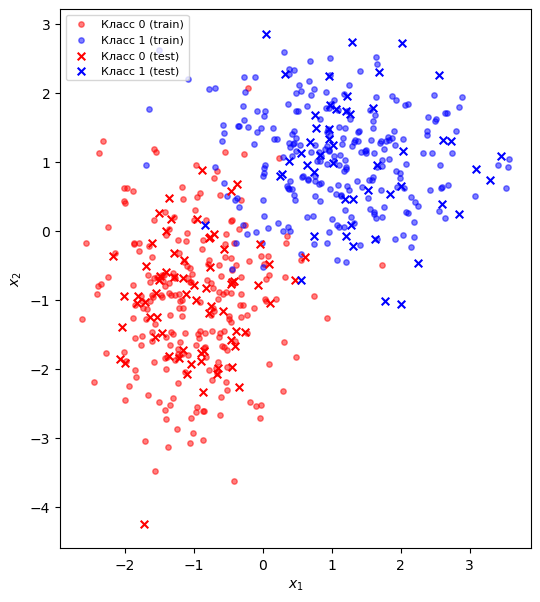

In [52]:
# Генерация данных с диагональными ковариациями
np.random.seed(int(42))

# Явно приводим всё к Python-типам, чтобы Sage не обернул
mu0_true = np.array([float(-1.0), float(-1.0)], dtype=np.float64)
var0_true = np.array([float(0.5), float(1.0)], dtype=np.float64)
C0_true = np.diag(var0_true).astype(np.float64)

mu1_true = np.array([float(1.0), float(1.0)], dtype=np.float64)
var1_true = np.array([float(1.0), float(0.5)], dtype=np.float64)
C1_true = np.diag(var1_true).astype(np.float64)

n_per_class = int(300)

X0 = np.random.multivariate_normal(mu0_true, C0_true, n_per_class)
X1 = np.random.multivariate_normal(mu1_true, C1_true, n_per_class)

# Принудительно конвертируем в нативный numpy (если Sage вернул свой тип)
X0 = np.asarray(X0, dtype=np.float64)
X1 = np.asarray(X1, dtype=np.float64)

X_nb = np.vstack([X0, X1])
y_nb = np.hstack([np.zeros(n_per_class), np.ones(n_per_class)])
X_nb = np.asarray(X_nb, dtype=np.float64)
y_nb = np.asarray(y_nb, dtype=np.float64)

# Разделение train/test вручную 
np.random.seed(int(0))
n_total = int(len(X_nb))
idx = np.asarray(np.random.permutation(n_total), dtype=np.int64)
n_train = int(0.8 * n_total)
tr = np.asarray(idx[:n_train], dtype=np.int64)
te = np.asarray(idx[n_train:], dtype=np.int64)

X_tr = np.asarray(X_nb[tr], dtype=np.float64)
X_te = np.asarray(X_nb[te], dtype=np.float64)
y_tr = np.asarray(y_nb[tr], dtype=np.float64)
y_te = np.asarray(y_nb[te], dtype=np.float64)

print("train:", X_tr.shape, "test:", X_te.shape)
print("type(X_tr):", type(X_tr), "dtype:", X_tr.dtype)

# Обучение MyNB 
my_nb = MyNB().fit(X_tr, y_tr)

# Сравнение оценок с истинными 
print("\n--- Класс 0 ---")
print("Истинное среднее:    ", mu0_true)
print("Оценённое среднее:   ", my_nb.means_[0])
print("Истинные дисперсии:  ", var0_true)
print("Оценённые дисперсии: ", my_nb.vars_[0])

print("\n--- Класс 1 ---")
print("Истинное среднее:    ", mu1_true)
print("Оценённое среднее:   ", my_nb.means_[1])
print("Истинные дисперсии:  ", var1_true)
print("Оценённые дисперсии: ", my_nb.vars_[1])

print("\n--- Приоры ---")
print("prior0 =", my_nb.priors_[0])
print("prior1 =", my_nb.priors_[1])

# Точность на тесте
pred = my_nb.predict(X_te)
acc = float(np.mean(pred == y_te))
print(f"\nMyNB accuracy: {acc:.4f}")

# Визуализация
# Срезы делаем через np.asarray с явным dtype — это гарантирует нативный тип
mask_tr_0 = np.asarray(y_tr == 0, dtype=bool)
mask_tr_1 = np.asarray(y_tr == 1, dtype=bool)
mask_te_0 = np.asarray(y_te == 0, dtype=bool)
mask_te_1 = np.asarray(y_te == 1, dtype=bool)

Xtr0 = np.asarray(X_tr[mask_tr_0], dtype=np.float64)
Xtr1 = np.asarray(X_tr[mask_tr_1], dtype=np.float64)
Xte0 = np.asarray(X_te[mask_te_0], dtype=np.float64)
Xte1 = np.asarray(X_te[mask_te_1], dtype=np.float64)

fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(Xtr0[:, 0], Xtr0[:, 1], s=15, c='red',  label='Класс 0 (train)', alpha=0.5)
ax.scatter(Xtr1[:, 0], Xtr1[:, 1], s=15, c='blue', label='Класс 1 (train)', alpha=0.5)
ax.scatter(Xte0[:, 0], Xte0[:, 1], s=30, c='red',  marker='x', label='Класс 0 (test)')
ax.scatter(Xte1[:, 0], Xte1[:, 1], s=30, c='blue', marker='x', label='Класс 1 (test)')

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_aspect('equal')
ax.legend(loc='upper left', fontsize=8)
plt.show()

## Часть 6. Экспериментальное сравнение LDA и NB (15 баллов)

### 6.1 Генерация датасетов с разной структурой
Создайте **три** различных датасета для бинарной классификации:

1. **Датасет A (LDA-оптимальный):** классы имеют одинаковую ковариацию, но разные средние.
2. **Датасет B (NB-оптимальный):** признаки независимы внутри каждого класса, но ковариации классов разные.
3. **Датасет C (сложный):** признаки коррелированы, ковариации классов разные.

Используйте `sklearn.datasets.make_classification` с параметрами:
- `n_features=10` (для проверки многомерности)
- `n_informative=5`, `n_redundant=2`
- Для датасета C: `flip_y=0.05` (немного шума).

In [53]:
np.random.seed(int(42))

d = int(10)              # размерность
n_per_class = int(500)   # по 500 точек на класс

# Датасет A: LDA-оптимальный
# Одинаковая полная ковариация для обоих классов

# Случайная положительно определённая ковариация
A_rand = np.random.randn(d, d)
C_A = A_rand @ A_rand.T / d + np.eye(d) * 0.5   # (d, d)
C_A = np.asarray(C_A, dtype=np.float64)

# Средние: разнесены на вектор d
mu_A0 = np.zeros(d)
mu_A1 = np.ones(d) * 1.2                        # разнесены

mu_A0 = np.asarray(mu_A0, dtype=np.float64)
mu_A1 = np.asarray(mu_A1, dtype=np.float64)

X_A0 = np.random.multivariate_normal(mu_A0, C_A, n_per_class)
X_A1 = np.random.multivariate_normal(mu_A1, C_A, n_per_class)
X_A = np.vstack([X_A0, X_A1])
y_A = np.hstack([np.zeros(n_per_class), np.ones(n_per_class)])

# Датасет B: NB-оптимальный 
# Диагональные (независимые) ковариации, разные для классов

var_B0 = np.linspace(0.5, 2.0, d)   # разброс по признакам у класса 0
var_B1 = np.linspace(2.0, 0.5, d)   # разброс по признакам у класса 1
C_B0 = np.diag(var_B0)
C_B1 = np.diag(var_B1)

mu_B0 = np.zeros(d)
mu_B1 = np.ones(d) * 1.2

X_B0 = np.random.multivariate_normal(mu_B0, C_B0, n_per_class)
X_B1 = np.random.multivariate_normal(mu_B1, C_B1, n_per_class)
X_B = np.vstack([X_B0, X_B1])
y_B = np.hstack([np.zeros(n_per_class), np.ones(n_per_class)])

# Датасет C: сложный 
# Коррелированные признаки, разные ковариации, шум в метках

C_C0 = np.asarray(C_A * 0.7, dtype=np.float64)   # другая ковариация для класса 0
C_C1 = np.asarray(C_A * 1.3, dtype=np.float64)   # другая ковариация для класса 1

mu_C0 = np.zeros(d)
mu_C1 = np.ones(d) * 0.8    # ближе, чем в A и B → сложнее

X_C0 = np.random.multivariate_normal(mu_C0, C_C0, n_per_class)
X_C1 = np.random.multivariate_normal(mu_C1, C_C1, n_per_class)
X_C = np.vstack([X_C0, X_C1])
y_C = np.hstack([np.zeros(n_per_class), np.ones(n_per_class)])

# Добавляем шум в метки: 5% меток случайно переворачиваем
n_total = int(len(y_C))
flip_mask = np.random.rand(n_total) < 0.05
y_C[flip_mask] = 1 - y_C[flip_mask]

# Явно приводим к нативным numpy
X_A = np.asarray(X_A, dtype=np.float64); y_A = np.asarray(y_A, dtype=np.float64)
X_B = np.asarray(X_B, dtype=np.float64); y_B = np.asarray(y_B, dtype=np.float64)
X_C = np.asarray(X_C, dtype=np.float64); y_C = np.asarray(y_C, dtype=np.float64)

print("Датасет A:", X_A.shape, "класс 0:", int(np.sum(y_A == 0)), "класс 1:", int(np.sum(y_A == 1)))
print("Датасет B:", X_B.shape, "класс 0:", int(np.sum(y_B == 0)), "класс 1:", int(np.sum(y_B == 1)))
print("Датасет C:", X_C.shape, "класс 0:", int(np.sum(y_C == 0)), "класс 1:", int(np.sum(y_C == 1)))

Датасет A: (1000, 10) класс 0: 500 класс 1: 500
Датасет B: (1000, 10) класс 0: 500 класс 1: 500
Датасет C: (1000, 10) класс 0: 491 класс 1: 509


### 6.2 Сравнение моделей
Для каждого датасета:
1. Разделите на train/test (80/20).
2. Обучите `MyLDA`, `MyNB`, а также (для бенчмарка) `sklearn.linear_model.LogisticRegression`.
3. Посчитайте метрики: **Accuracy**, **Precision**, **Recall**, **F1-score** (для каждого класса отдельно и macro-усредненные).
4. Постройте confusion matrix для каждой модели.


=== A (LDA-opt) ===
Model       Acc   Prec    Rec     F1
MyLDA     0.520  0.758  0.510  0.360
MyNB      0.975  0.975  0.975  0.975
Confusion matrices:
  MyLDA:
[[  2  96]
 [  0 102]]
  MyNB:
[[96  2]
 [ 3 99]]

=== B (NB-opt) ===
Model       Acc   Prec    Rec     F1
MyLDA     0.525  0.759  0.515  0.371
MyNB      0.965  0.965  0.965  0.965
Confusion matrices:
  MyLDA:
[[  3  95]
 [  0 102]]
  MyNB:
[[94  4]
 [ 3 99]]

=== C (сложный) ===
Model       Acc   Prec    Rec     F1
MyLDA     0.565  0.780  0.511  0.381
MyNB      0.865  0.866  0.871  0.865
Confusion matrices:
  MyLDA:
[[  2  87]
 [  0 111]]
  MyNB:
[[82  7]
 [20 91]]


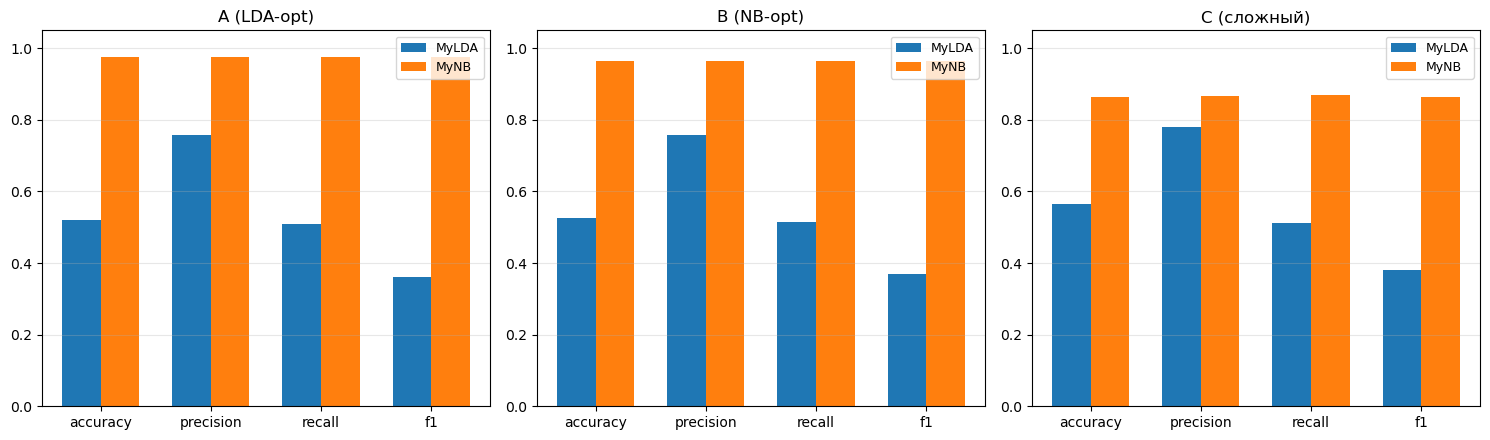

In [56]:
def train_test_split_manual(X, y, test_size=0.2, seed=0):
    """Простое разделение без sklearn."""
    np.random.seed(int(seed))
    n = int(len(X))
    idx = np.asarray(np.random.permutation(n), dtype=np.int64)
    n_test = int(n * test_size)
    te, tr = idx[:n_test], idx[n_test:]
    return (np.asarray(X[tr], dtype=np.float64),
            np.asarray(X[te], dtype=np.float64),
            np.asarray(y[tr], dtype=np.float64),
            np.asarray(y[te], dtype=np.float64))


def metrics(y_true, y_pred):
    """Accuracy, macro Precision, Recall, F1, confusion matrix."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    classes = np.unique(y_true)
    K = int(len(classes))
    cm = np.zeros((K, K), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1
    acc = float(np.trace(cm) / np.sum(cm))
    precisions, recalls, f1s = [], [], []
    for c in range(K):
        tp = float(cm[c, c])
        fp = float(cm[:, c].sum() - tp)
        fn = float(cm[c, :].sum() - tp)
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        precisions.append(prec); recalls.append(rec); f1s.append(f1)
    return {
        'accuracy':  acc,
        'precision': float(np.mean(precisions)),
        'recall':    float(np.mean(recalls)),
        'f1':        float(np.mean(f1s)),
        'cm':        cm,
    }

datasets = {
    'A (LDA-opt)': (X_A, y_A),
    'B (NB-opt)':  (X_B, y_B),
    'C (сложный)': (X_C, y_C),
}

results = {}

for name, (X, y) in datasets.items():
    X_tr, X_te, y_tr, y_te = train_test_split_manual(X, y, test_size=0.2, seed=0)

    rows = []
    for model_name, model in [('MyLDA', MyLDA()), ('MyNB', MyNB())]:
        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)
        m = metrics(y_te, pred)
        m['model'] = model_name
        rows.append(m)

    results[name] = rows

    print(f"\n=== {name} ===")
    print(f"{'Model':<8} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6}")
    for r in rows:
        print(f"{r['model']:<8} {r['accuracy']:>6.3f} {r['precision']:>6.3f} "
              f"{r['recall']:>6.3f} {r['f1']:>6.3f}")
    print("Confusion matrices:")
    for r in rows:
        print(f"  {r['model']}:\n{r['cm']}")

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics_names = ['accuracy', 'precision', 'recall', 'f1']

for ax, (name, rows) in zip(axes, results.items()):
    x = np.arange(len(metrics_names))
    width = 0.35
    for i, r in enumerate(rows):
        vals = [r[m] for m in metrics_names]
        ax.bar(x + i * width, vals, width, label=r['model'])
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(metrics_names)
    ax.set_ylim(0, 1.05)
    ax.set_title(name)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 6.3 Анализ результатов
В Markdown-ячейке напишите **развернутый вывод**:
- На каком датасете LDA превосходит NB? Почему?
- На каком датасете NB работает лучше? Почему?
- Как влияет размерность пространства на обе модели?
- Когда обе модели падают (датасет C) — почему?

**Визуализация:** для каждого датасета постройте столбчатую диаграмму сравнения метрик.

1. 